In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import sys


repo_path = Path("../../anomolous_ts")
if str(repo_path) not in sys.path:
    sys.path.append(str(repo_path))

#import ..anomolous_ts
from anomolous_ts import fitter


Testing statistical method:
Found 0 anomalies
First 5 anomalies:


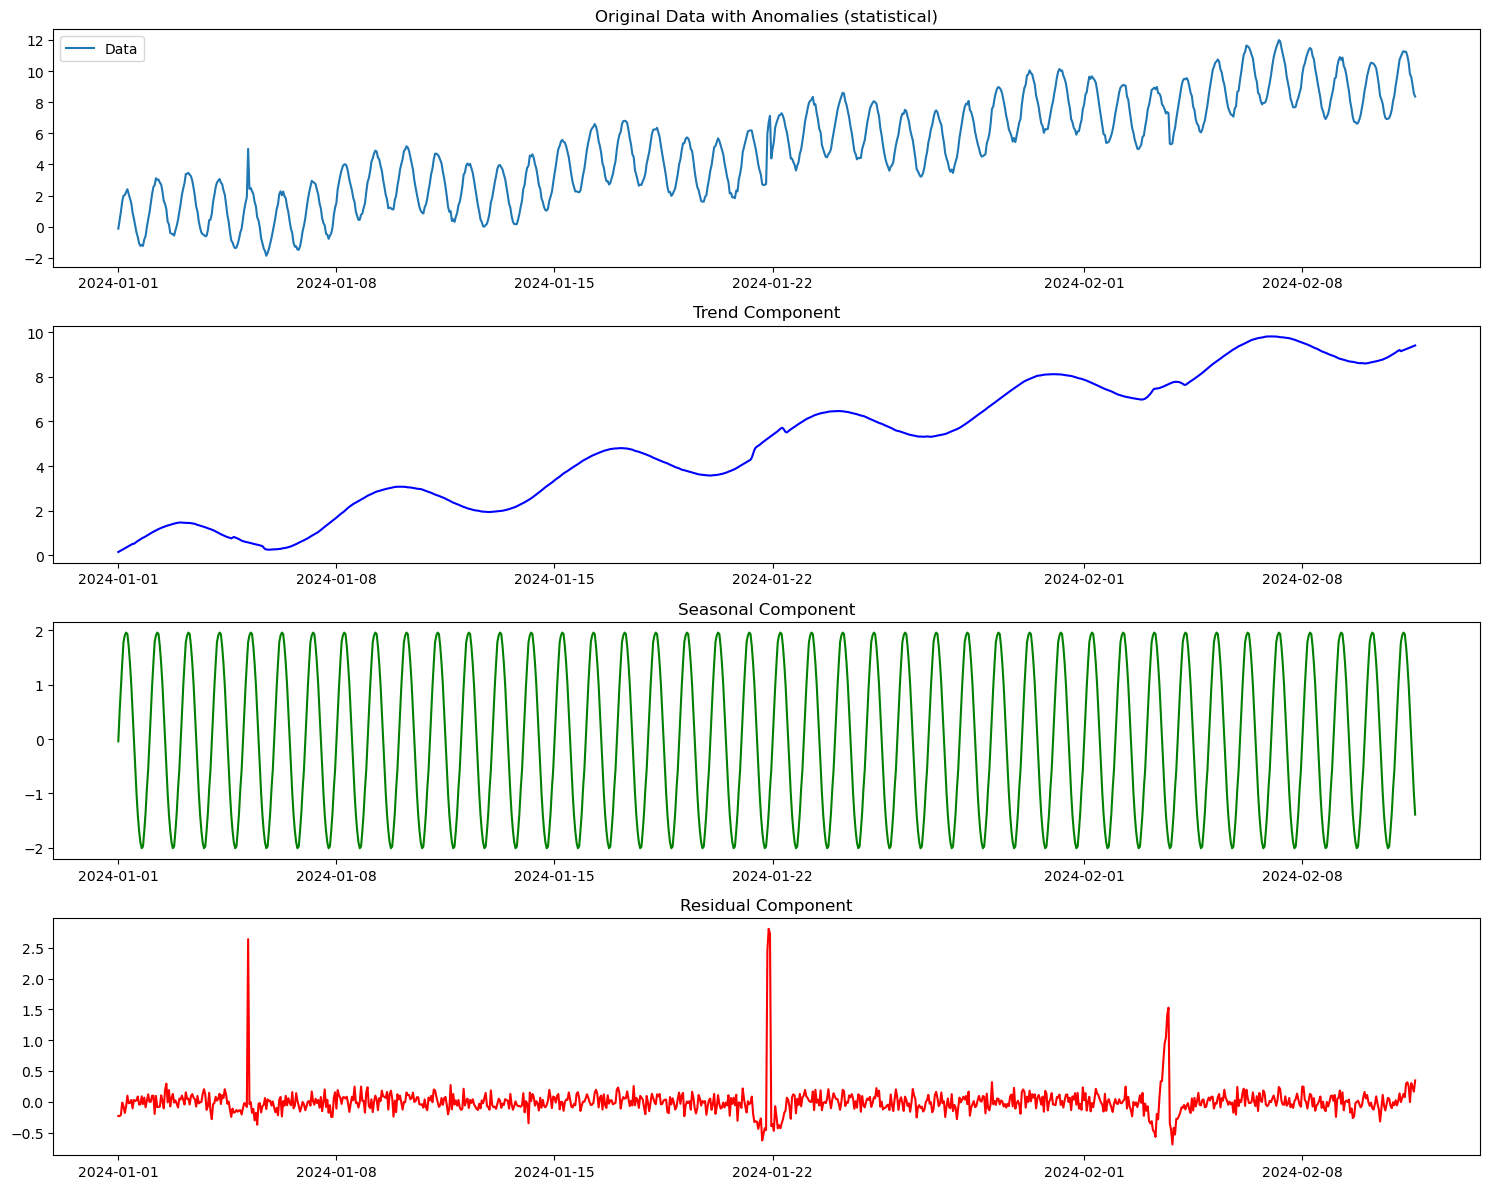


Testing isolation_forest method:
Found 1000 anomalies
First 5 anomalies:
Timestamp: 2024-01-01 00:00:00
Score: 0.62
Type: point
Seasonal strength: 0.10
Trend strength: 0.35
---
Timestamp: 2024-01-01 01:00:00
Score: 0.62
Type: seasonal
Seasonal strength: 0.54
Trend strength: 0.20
---
Timestamp: 2024-01-01 02:00:00
Score: 0.62
Type: seasonal
Seasonal strength: 0.69
Trend strength: 0.15
---
Timestamp: 2024-01-01 03:00:00
Score: 0.62
Type: seasonal
Seasonal strength: 0.84
Trend strength: 0.15
---
Timestamp: 2024-01-01 04:00:00
Score: 0.61
Type: seasonal
Seasonal strength: 0.83
Trend strength: 0.13
---


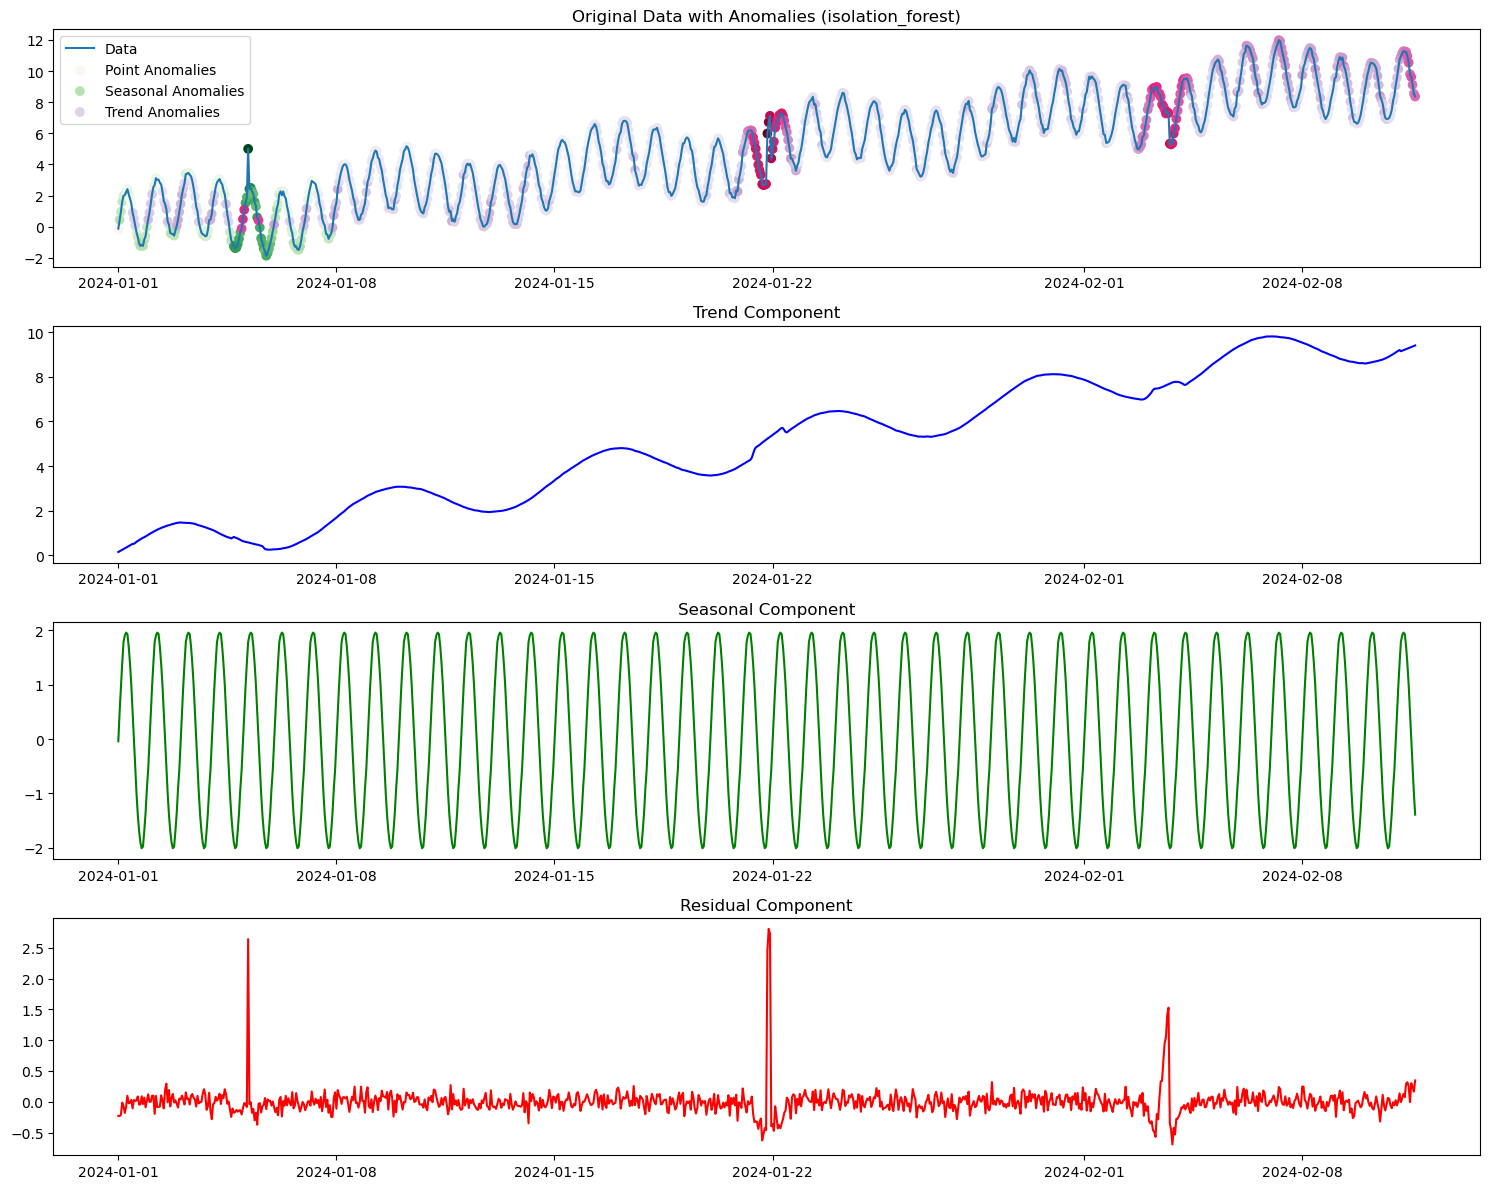


Testing kmeans method:


C:\Users\paulinkenbrandt\Anaconda3\envs\pygis12\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Found 12 anomalies
First 5 anomalies:
Timestamp: 2024-01-05 04:00:00
Score: 1.00
Type: seasonal
Seasonal strength: 0.36
Trend strength: 0.12
---
Timestamp: 2024-01-05 05:00:00
Score: 1.00
Type: seasonal
Seasonal strength: 0.76
Trend strength: 0.22
---
Timestamp: 2024-01-05 06:00:00
Score: 0.73
Type: seasonal
Seasonal strength: 0.78
Trend strength: 0.22
---
Timestamp: 2024-01-21 20:00:00
Score: 1.00
Type: trend
Seasonal strength: 0.18
Trend strength: 0.56
---
Timestamp: 2024-01-21 21:00:00
Score: 1.00
Type: trend
Seasonal strength: 0.14
Trend strength: 0.56
---


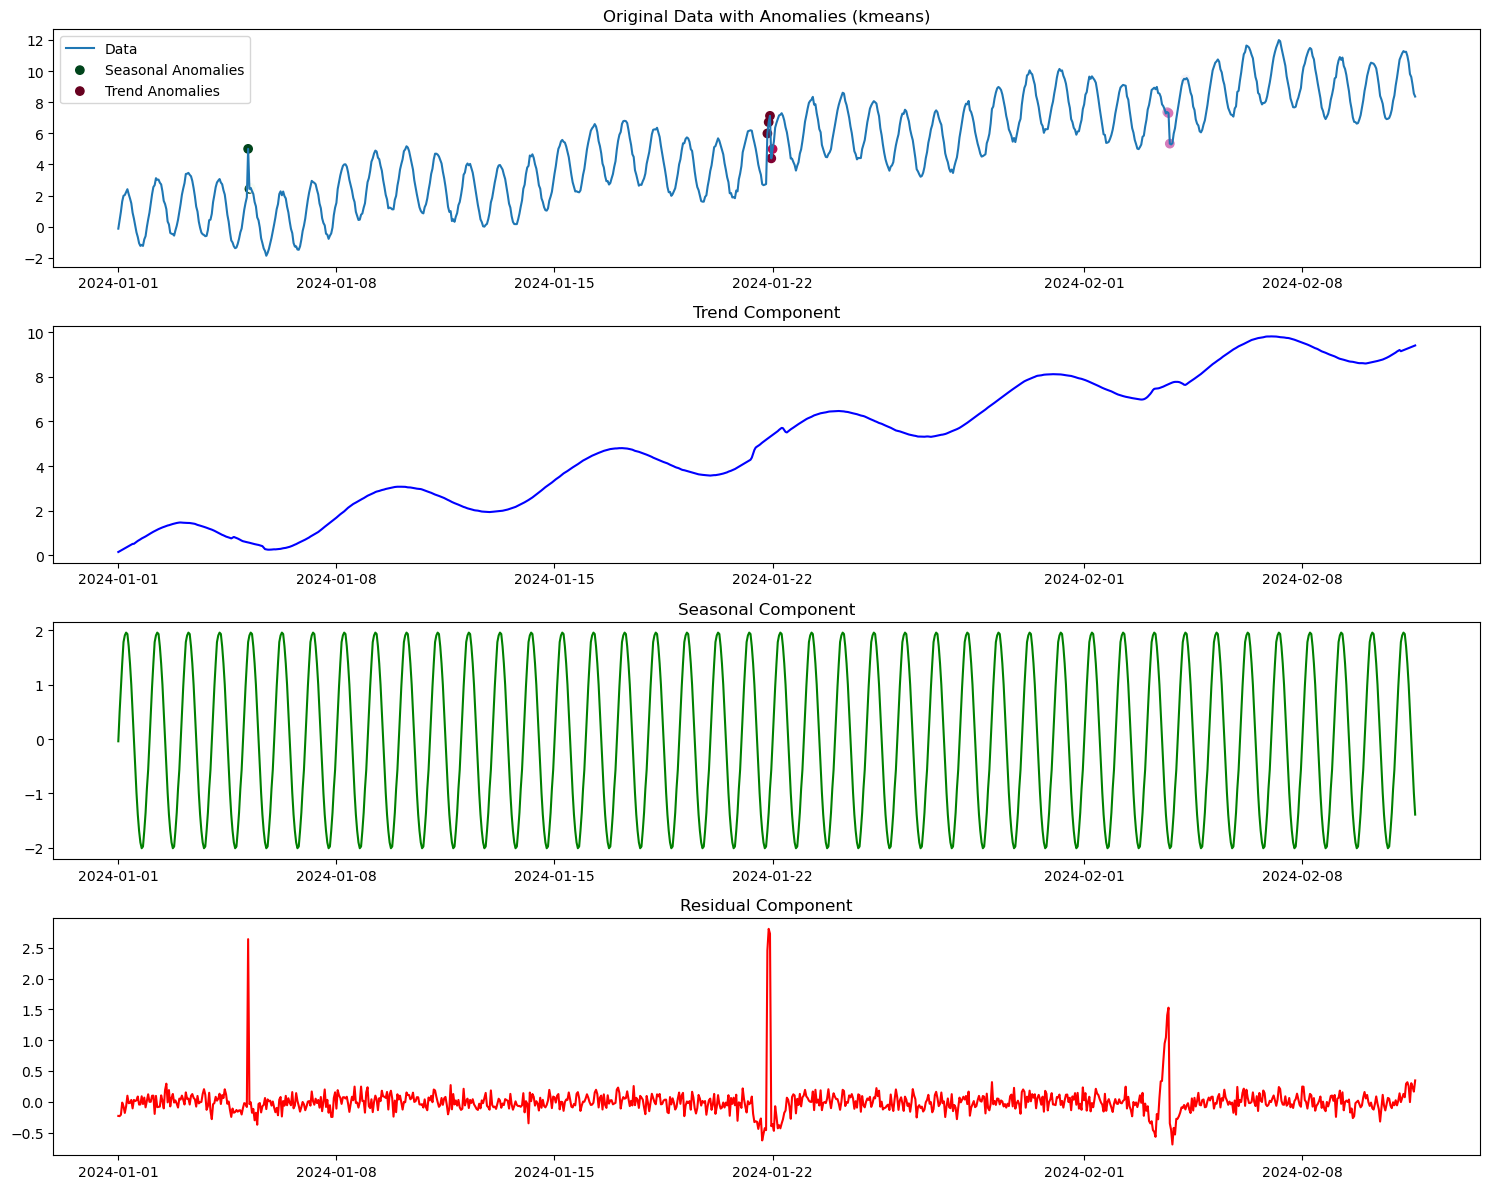

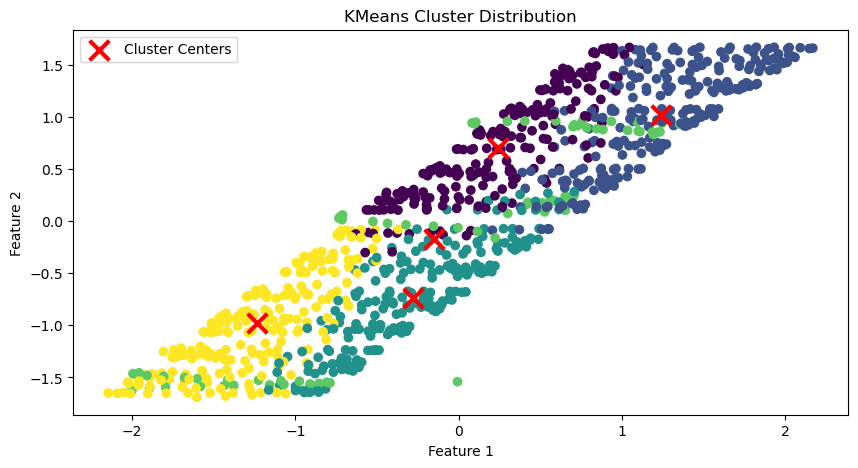


Testing prophet method:


C:\Users\paulinkenbrandt\Documents\GitHub\anomolous_ts\notebooks\..\..\anomolous_ts\anomolous_ts\fitter.py:146: UserWarning: Prophet detection failed: Prophet detection failed: Prophet model fitting failed: Prophet.__init__() got an unexpected keyword argument 'cap'. Falling back to statistical method.
  warnings.warn(


Found 0 anomalies
First 5 anomalies:


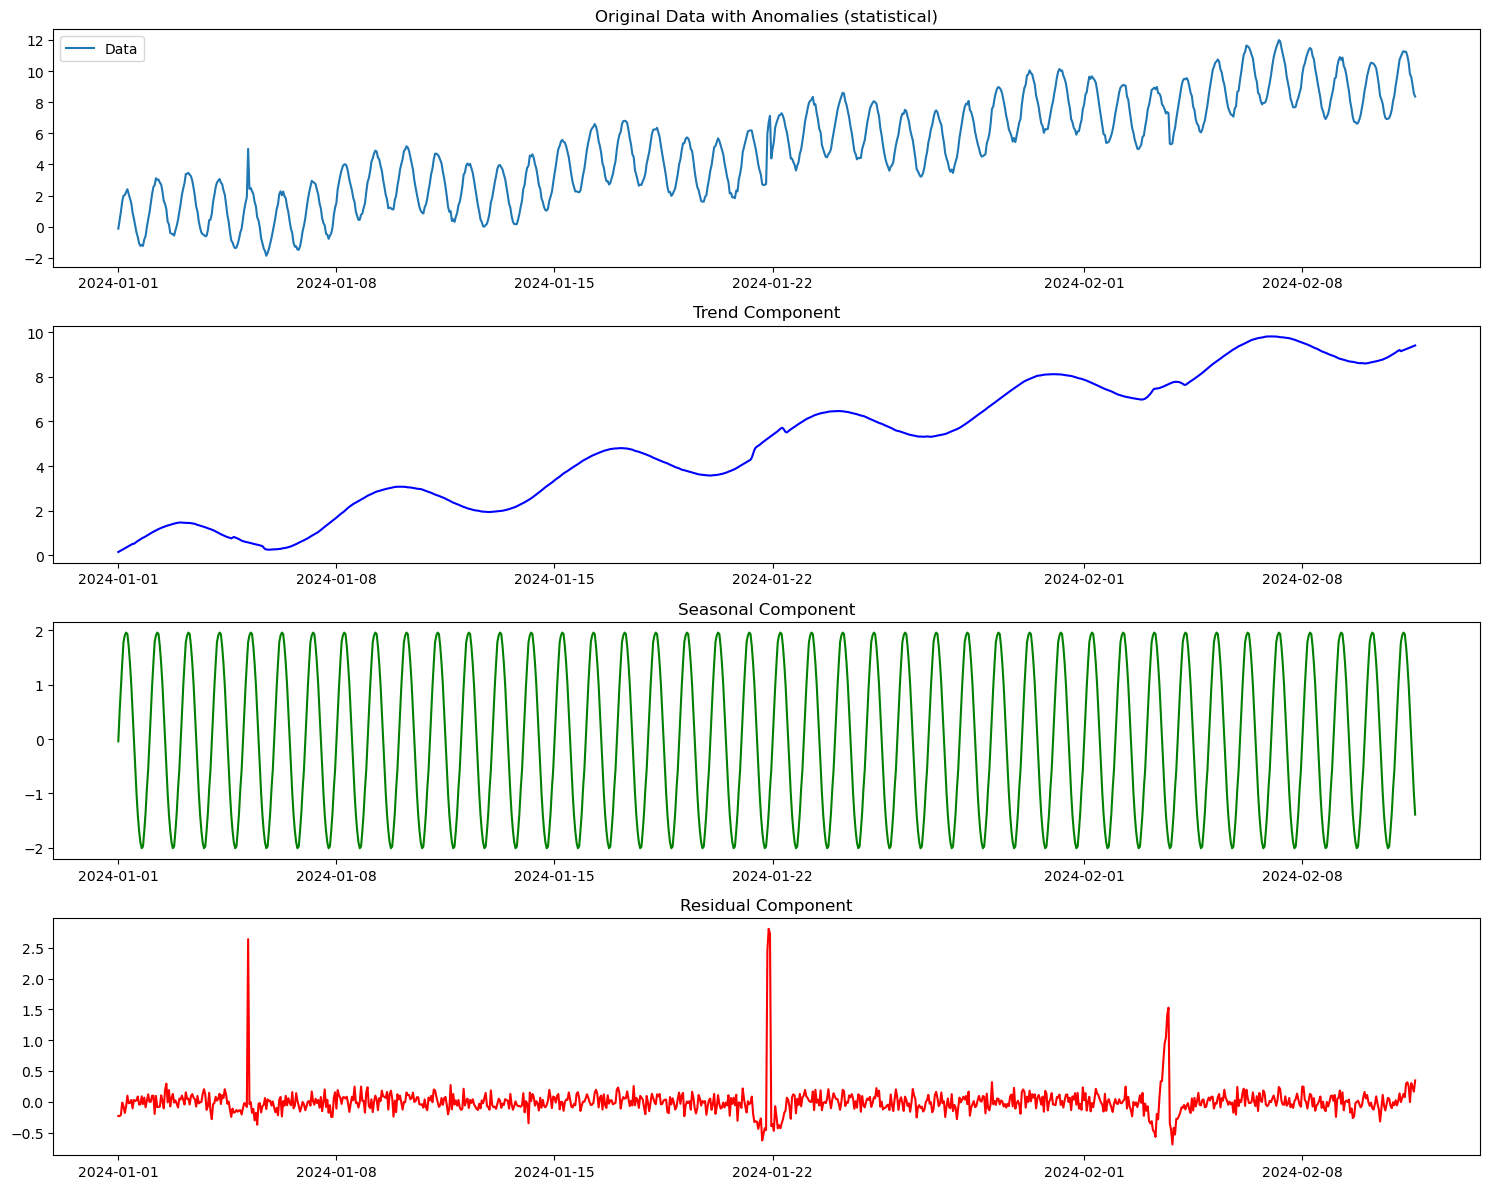

In [2]:
# Generate sample data with seasonality
dates = pd.date_range('2024-01-01', periods=1000, freq='h')
# Daily seasonality
seasonal = 2 * np.sin(2 * np.pi * np.arange(1000) / 24)
# Weekly seasonality
seasonal += np.sin(2 * np.pi * np.arange(1000) / (24 * 7))
# Trend
trend = 0.01 * np.arange(1000)
# Noise
noise = np.random.normal(0, 0.1, 1000)

# Combine components
values = seasonal + trend + noise

# Add some obvious anomalies
values[100] = 5.0  # Point anomaly
values[500:503] += 3.0  # Seasonal anomaly
values[800:810] += np.linspace(0, 2, 10)  # Trend anomaly

# Create time series
data = pd.Series(values, index=dates)

# Test all detection methods
for method in fitter.DetectionMethod:
    print(f"\nTesting {method.value} method:")
    detector = fitter.TimeSeriesDetector(
        method=method,
        seasonal_period=24,  # Known daily seasonality
        n_clusters=5 if method == fitter.DetectionMethod.KMEANS else None
    )
    anomalies = detector.detect(data)
    
    print(f"Found {len(anomalies)} anomalies")
    print("First 5 anomalies:")
    for anomaly in anomalies[:5]:
        print(f"Timestamp: {anomaly.timestamp}")
        print(f"Score: {anomaly.score:.2f}")
        print(f"Type: {anomaly.anomaly_type}")
        print(f"Seasonal strength: {anomaly.seasonal_strength:.2f}")
        print(f"Trend strength: {anomaly.trend_strength:.2f}")
        print("---")
    
    # Plot results
    detector.plot(data, anomalies)